# An example of analysing individual MBHB in LDC

In this script, we will verify verious key functions in `pespace` with data released in LISA data challenge (LDC), like noise realization generation, response generation, etc. An example of analysing individual MBHB with stationary Gaussian noise are presented.

Two data files are needed in codes below, `LDC1-1_MBHB_v1_1_TD.hdf5` and `LDC1-1_MBHB_v1_1_TD_noiseless.hdf5`, which can be downloaded from https://lisa-ldc.lal.in2p3.fr/.

In [26]:
# import necessory packages and modules
import sys
sys.path.append("/home/changfenggroup/nrui/works/codes/gw_space/pespace")
sys.path.append("/home/changfenggroup/nrui/works/codes/gw_space/tiwave")
sys.path.append('/home/hydrogen/workspace/Space_GW/pespace')
sys.path.append('/home/hydrogen/workspace/Space_GW/tiwave')
import os
from pathlib import Path

import numpy as np
import taichi as ti
import bilby
import h5py
from matplotlib import pyplot as plt

from pespace.constants import DAY_SI, PI
from pespace.detectors import TDIChannelsData, SpaceborneInterferometer
from pespace.likelihood import FrequencyDomainLikelihood
from pespace.orbits import KaplerianHeliocentric
from tiwave.waveforms import IMRPhenomD
from tiwave.constants import PC_SI

label = "LDC1-1_v1_MBHB"
outdir = f"output/outdir_{label}"
Path(outdir).mkdir(exist_ok=True)

ti.init(arch=ti.cpu, cpu_max_num_threads=1, default_fp=ti.f64, offline_cache=False)



[Taichi] Starting on arch=x64


## Response generation

In [27]:
# Read in the data and print data info
dataname = "LDC1-1_MBHB_v1_1_FD_noiseless"
file_path = f"/home/hydrogen/workspace/Space_GW/LDC/LDC_data/{dataname}.hdf5"
with h5py.File(file_path, "r") as f:
    f.visit(lambda name: print(name))

    source_parameters = {}
    print('Source information: ')
    for parameter, value in f["H5LISA/GWSources/MBHB-0"].items():
        print(f"{parameter}: {value[()]}")
        source_parameters[parameter] = value[()]

    # print(f["H5LISA/PreProcess/TDIGenerator"][()])
    TDI_data = f["H5LISA/PreProcess/TDIdata"][()]
    print(TDI_data)
    print(TDI_data.shape)

# # Source information:
# Approximant: b'IMRPhenomD'
# AzimuthalAngleOfSpin1: 0.6171792478977071
# AzimuthalAngleOfSpin2: 4.75979656623224
# Cadence: 10.0
# CoalescenceTime: 25135000.0
# Distance: 60.42017466175677
# EclipticLatitude: -0.5256036732051035
# EclipticLongitude: 1.1637
# InitialAzimuthalAngleL: 0.30782038099413395
# InitialPolarAngleL: 1.2498
# Mass1: 2803843.776
# Mass2: 285210.246
# ObservationDuration: 41943040.0
# PhaseAtCoalescence: 2.596553404898615
# PolarAngleOfSpin1: 0.0
# PolarAngleOfSpin2: 0.0
# Redshift: 6.1178
# Spin1: 0.8986046314480332
# Spin2: 0.9465882372512956
# b'X,Y,Z'
# (4194304, 4)

H5LISA
H5LISA/Author
H5LISA/GWSources
H5LISA/GWSources/MBHB-0
H5LISA/GWSources/MBHB-0/Approximant
H5LISA/GWSources/MBHB-0/AzimuthalAngleOfSpin1
H5LISA/GWSources/MBHB-0/AzimuthalAngleOfSpin2
H5LISA/GWSources/MBHB-0/Cadence
H5LISA/GWSources/MBHB-0/CoalescenceTime
H5LISA/GWSources/MBHB-0/Distance
H5LISA/GWSources/MBHB-0/EclipticLatitude
H5LISA/GWSources/MBHB-0/EclipticLongitude
H5LISA/GWSources/MBHB-0/InitialAzimuthalAngleL
H5LISA/GWSources/MBHB-0/InitialPolarAngleL
H5LISA/GWSources/MBHB-0/Mass1
H5LISA/GWSources/MBHB-0/Mass2
H5LISA/GWSources/MBHB-0/ObservationDuration
H5LISA/GWSources/MBHB-0/PhaseAtCoalescence
H5LISA/GWSources/MBHB-0/PolarAngleOfSpin1
H5LISA/GWSources/MBHB-0/PolarAngleOfSpin2
H5LISA/GWSources/MBHB-0/Redshift
H5LISA/GWSources/MBHB-0/Spin1
H5LISA/GWSources/MBHB-0/Spin2
H5LISA/History
H5LISA/History/0000
H5LISA/History/0001
H5LISA/History/0002
H5LISA/History/0003
H5LISA/PreProcess
H5LISA/PreProcess/TDIdata
H5LISA/UserRequest
H5LISA/UserRequest/ConfigParams
H5LISA/UserRequest

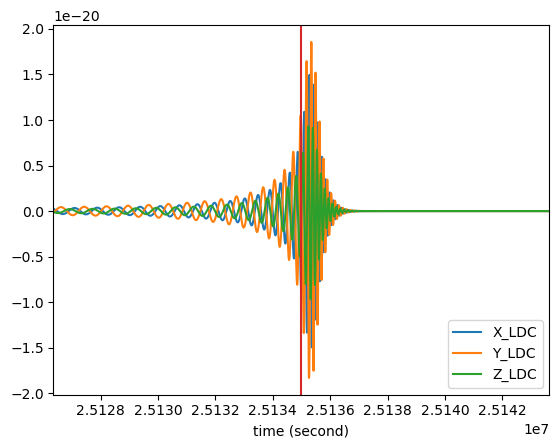

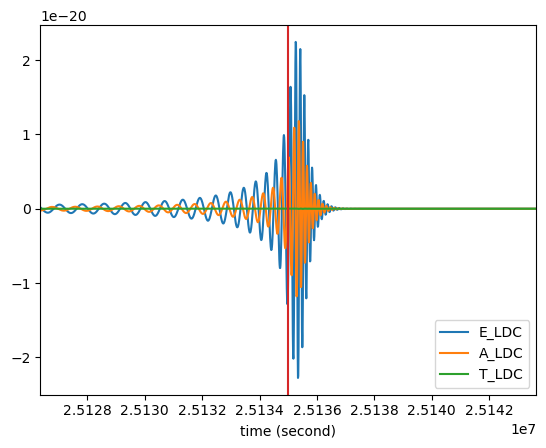

In [28]:
tc = source_parameters["CoalescenceTime"]
time_array, X_array, Y_array, Z_array = TDI_data.T
A_array = (Z_array - X_array)/np.sqrt(2)
E_array = (X_array - 2*Y_array + Z_array)/np.sqrt(6)
T_array = (X_array + Y_array + Z_array)/np.sqrt(3)

plt.figure()
plt.plot(time_array, X_array, label='X_LDC')
plt.plot(time_array, Y_array, label='Y_LDC')
plt.plot(time_array, Z_array, label='Z_LDC')
plt.xlim(tc-0.1*DAY_SI, tc+0.1*DAY_SI)
plt.axvline(tc, color='tab:red')
plt.xlabel("time (second)")
plt.legend(loc='lower right')
plt.savefig(f"{outdir}/{dataname}_raw_data_XYZ.png")

plt.figure()
plt.plot(time_array, E_array, label='E_LDC')
plt.plot(time_array, A_array, label='A_LDC')
plt.plot(time_array, T_array, label='T_LDC')
plt.axvline(tc, color='tab:red')
plt.xlim(tc-0.1*DAY_SI, tc+0.1*DAY_SI)
plt.xlabel("time (second)")
plt.legend(loc='lower right')
plt.savefig(f"{outdir}/{dataname}_raw_data_AET.png")


`waveform_container` is not given, initializing one with returned_form=polarizations, include_tf=True
f_peak: 0.006633553090381121


/tmp/ipykernel_2995970/3130623099.py:49: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(tc-DAY_SI, tc-DAY_SI)


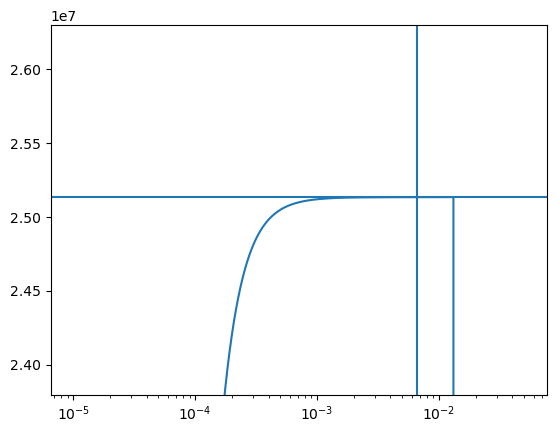

In [29]:
# Transform to frequency domain
cadence = source_parameters["Cadence"]
end_idx = int((tc + 0.2*DAY_SI) // cadence)
# start_idx = int((tc - 300*DAY_SI) // cadence)
start_idx = 0
input_TDI_data_array = np.array([A_array[start_idx:end_idx], 
                                 E_array[start_idx:end_idx], 
                                 T_array[start_idx:end_idx]])
time_zoomin = time_array[start_idx:end_idx]
duration = time_zoomin[-1] - time_zoomin[0]

# cadence = source_parameters["Cadence"]
# duration = time_array[-1] - time_array[0]
# input_TDI_data_array = np.array([A_array, E_array, T_array])

TDI_chans = ("A", "E", "T")
TDI_gen = "1.5"
LDC_mbhb = TDIChannelsData(label="LDC_noiseless-MBHB", minimum_frequency=1e-5, maximum_frequency=0.1)
LDC_mbhb.set_time_domain_data_from_input_array(channels=TDI_chans, 
                                               generation=TDI_gen, 
                                               duration=duration, 
                                               cadence=cadence,
                                               TDI_data_array=input_TDI_data_array,
                                               start_time=time_zoomin[0])
LDC_mbhb.Fourier_transform_time_domain_data_to_frequency_domain()

params_tiwave= dict(
    mass_1 = source_parameters["Mass1"],
    mass_2 = source_parameters["Mass2"],
    chi_1 = source_parameters["Spin1"],
    chi_2 = source_parameters["Spin2"],
    luminosity_distance = source_parameters["Distance"]*1000,  # note the LDC using the unit of Gpc
    inclination = source_parameters["InitialPolarAngleL"],
    reference_phase = source_parameters["PhaseAtCoalescence"], # remember setting the reference_frequency to coalescence frequency
    coalescence_time = source_parameters["CoalescenceTime"],
    ecliptic_latitude = source_parameters["EclipticLatitude"],
    ecliptic_longitude = source_parameters["EclipticLongitude"],
    polarization = source_parameters["InitialAzimuthalAngleL"],
)
params_tiwave = bilby.gw.conversion.generate_mass_parameters(params_tiwave)
wf = IMRPhenomD(LDC_mbhb.frequency_samples)
wf.update_waveform(params_tiwave)
f_peak = wf.amplitude_coefficients[None].f_peak/wf.source_parameters.M_sec
print(f"f_peak: {f_peak}")

wf_data = wf.numpy_array_of_waveform_container()
plt.figure()
plt.semilogx(wf.frequencies.to_numpy(), wf_data['tf'])
plt.ylim(tc-DAY_SI, tc-DAY_SI)
plt.axhline(tc)
plt.axvline(f_peak)


# plt.figure()
# plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
#            np.abs(LDC_mbhb.frequency_domain_TDI_data_numpy_array['E']),
#            label="E_LDC")
# plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
#            np.abs(LDC_mbhb.frequency_domain_TDI_data_numpy_array['A']),
#            label="A_LDC")
# plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
#            np.abs(LDC_mbhb.frequency_domain_TDI_data_numpy_array['T']),
#            label="T_LDC")
# plt.axvline(f_peak, color='tab:red')
# plt.xlabel("frequency (Hz)")
# plt.ylabel("amplitude")
# plt.legend(loc="upper left")
# plt.savefig(f"{outdir}/{dataname}_td_to_fd_amplitude.png")

# plt.figure()
# plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
#            LDC_mbhb.frequency_domain_TDI_data_numpy_array['E'].real,
#            label="E_LDC")
# plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
#            LDC_mbhb.frequency_domain_TDI_data_numpy_array['A'].real,
#            label="A_LDC")
# plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
#            LDC_mbhb.frequency_domain_TDI_data_numpy_array['T'].real,
#            label="T_LDC")
# plt.axvline(f_peak, color='tab:red')
# plt.xlabel("frequency (Hz)")
# plt.ylabel("real part")
# plt.legend(loc="upper left")
# plt.savefig(f"{outdir}/{dataname}_td_to_fd_real.png")

# # zoom in around f_peak
# plt.figure()
# plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
#            LDC_mbhb.frequency_domain_TDI_data_numpy_array['E'].real,
#            label="E_LDC")
# plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
#            LDC_mbhb.frequency_domain_TDI_data_numpy_array['A'].real,
#            label="A_LDC")
# plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
#            LDC_mbhb.frequency_domain_TDI_data_numpy_array['T'].real,
#            label="T_LDC")
# plt.axvline(f_peak, color='tab:red')
# plt.xlabel("frequency (Hz)")
# plt.ylabel("real part")
# plt.xlim(f_peak-5e-3, f_peak+3e-3)
# plt.legend(loc="upper left")
# plt.savefig(f"{outdir}/{dataname}_td_to_fd_real_zoomin.png")




`waveform_container` is not given, initializing one with returned_form=polarizations, include_tf=True


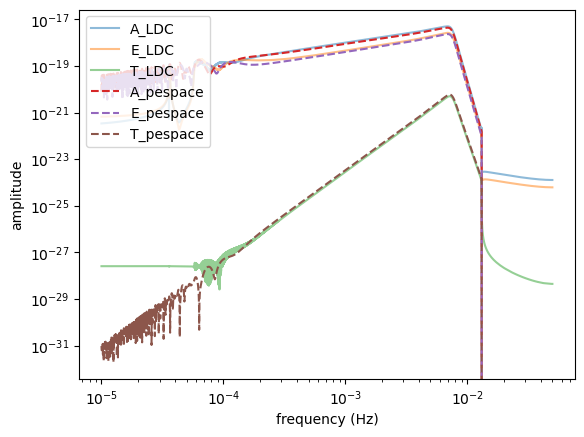

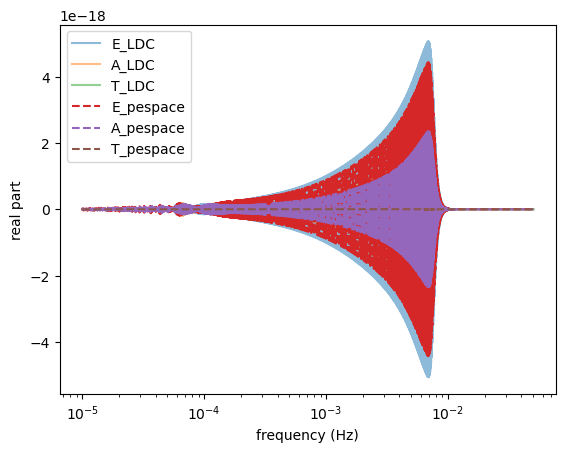

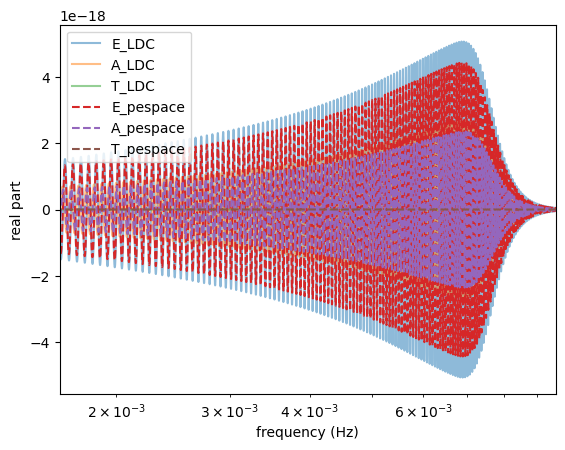

In [30]:
# Comparing with response generated by pespace
pespace_mbhb = TDIChannelsData(label="pespace_noiseless-MBHB", minimum_frequency=1e-5, maximum_frequency=0.1)
pespace_mbhb.set_frequency_domain_data_with_zero_value(channels=TDI_chans, 
                                                       generation=TDI_gen, 
                                                       duration=duration, 
                                                       cadence=cadence,)
wf = IMRPhenomD(pespace_mbhb.frequency_samples, reference_frequency=f_peak)
wf.update_waveform(params_tiwave)
lisa = SpaceborneInterferometer(name='LISA', TDI_data=pespace_mbhb, orbit=KaplerianHeliocentric(2.5e9, 0.0, 0.0))
lisa.initialize_response_container_in_frequency_domain()
lisa.inject_frequency_domain_signal(wf.waveform_container, 
                                    params_tiwave['ecliptic_longitude'], 
                                    params_tiwave['ecliptic_latitude'], 
                                    params_tiwave['polarization'])

plt.figure()
plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
             np.abs(LDC_mbhb.frequency_domain_TDI_data_numpy_array['E']),
             label="A_LDC", alpha=0.5)
plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
             np.abs(LDC_mbhb.frequency_domain_TDI_data_numpy_array['A']),
             label="E_LDC", alpha=0.5)
plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
             np.abs(LDC_mbhb.frequency_domain_TDI_data_numpy_array['T']),
             label="T_LDC", alpha=0.5)
plt.loglog(lisa.TDI_data.data_info.frequency_samples_array, 
             np.abs(lisa.TDI_data.frequency_domain_TDI_data_numpy_array['E']),
             label="A_pespace", linestyle="dashed")
plt.loglog(lisa.TDI_data.data_info.frequency_samples_array, 
             np.abs(lisa.TDI_data.frequency_domain_TDI_data_numpy_array['A']),
             label="E_pespace", linestyle="dashed")
plt.loglog(lisa.TDI_data.data_info.frequency_samples_array, 
             np.abs(lisa.TDI_data.frequency_domain_TDI_data_numpy_array['T']),
             label="T_pespace", linestyle="dashed")
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.legend(loc="upper left")
plt.savefig(f"{outdir}/{dataname}_pespace_LDC_fd_abs.png")

plt.figure()
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
             LDC_mbhb.frequency_domain_TDI_data_numpy_array['E'].real,
             label="E_LDC", alpha=0.5)
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
             LDC_mbhb.frequency_domain_TDI_data_numpy_array['A'].real,
             label="A_LDC", alpha=0.5)
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
             LDC_mbhb.frequency_domain_TDI_data_numpy_array['T'].real,
             label="T_LDC", alpha=0.5)
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
             lisa.TDI_data.frequency_domain_TDI_data_numpy_array['E'].real,
             label="E_pespace", linestyle="dashed")
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
             lisa.TDI_data.frequency_domain_TDI_data_numpy_array['A'].real,
             label="A_pespace", linestyle="dashed")
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
             lisa.TDI_data.frequency_domain_TDI_data_numpy_array['T'].real,
             label="T_pespace", linestyle="dashed")
plt.xlabel("frequency (Hz)")
plt.ylabel("real part")
plt.legend(loc="upper left")
plt.savefig(f"{outdir}/{dataname}_pespace_LDC_fd_real.png")

plt.figure()
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
             LDC_mbhb.frequency_domain_TDI_data_numpy_array['E'].real,
             label="E_LDC", alpha=0.5)
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
             LDC_mbhb.frequency_domain_TDI_data_numpy_array['A'].real,
             label="A_LDC", alpha=0.5)
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
             LDC_mbhb.frequency_domain_TDI_data_numpy_array['T'].real,
             label="T_LDC", alpha=0.5)
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
             lisa.TDI_data.frequency_domain_TDI_data_numpy_array['E'].real,
             label="E_pespace", linestyle="dashed")
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
             lisa.TDI_data.frequency_domain_TDI_data_numpy_array['A'].real,
             label="A_pespace", linestyle="dashed")
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
             lisa.TDI_data.frequency_domain_TDI_data_numpy_array['T'].real,
             label="T_pespace", linestyle="dashed")
plt.xlabel("frequency (Hz)")
plt.ylabel("real part")
plt.legend(loc="upper left")
plt.xlim(f_peak-5e-3, f_peak+3e-3)
plt.savefig(f"{outdir}/{dataname}_pespace_LDC_fd_real_zooming.png")


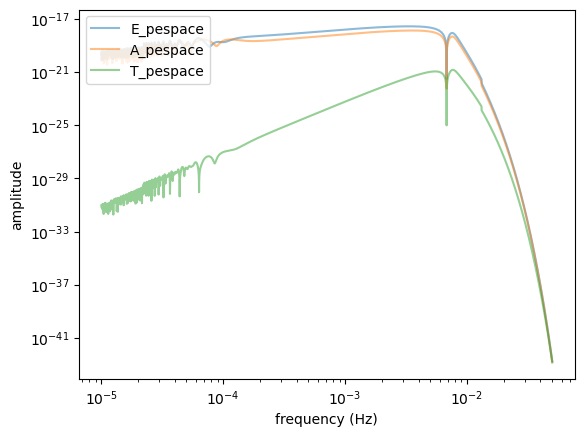

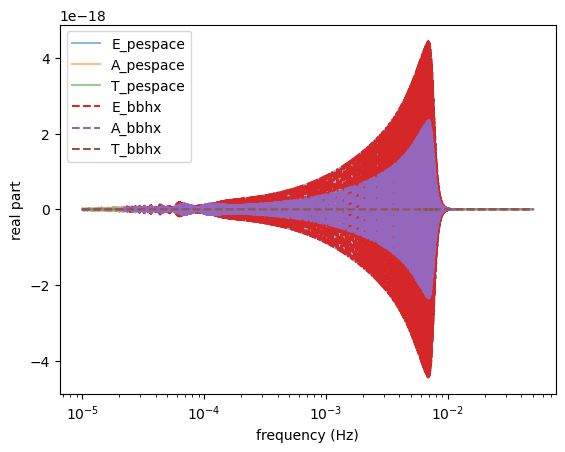

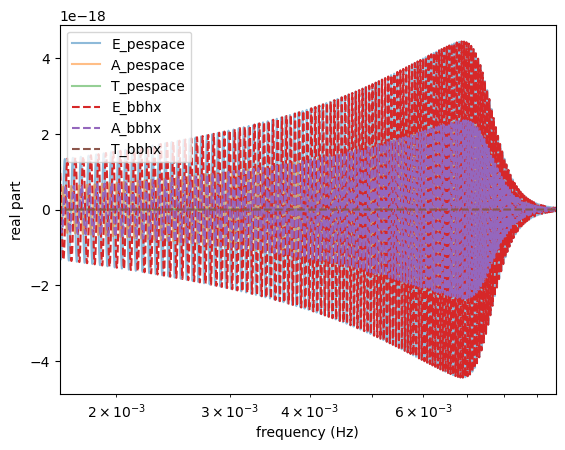

In [31]:
# Comparing with bbhx (https://github.com/mikekatz04/BBHx)
from bbhx.waveformbuild import BBHWaveformFD
wave_gen = BBHWaveformFD(amp_phase_kwargs={'run_phenomd': True,}, 
                        response_kwargs={'TDItag':'AET',}, 
                        interp_kwargs={},
                        use_gpu=False)
# https://mikekatz04.github.io/BBHx/html/user/main.html#bbhx.waveformbuild.BBHWaveformFD.__call__
# BBHWaveformFD.__call__(m1, m2, chi1z, chi2z, distance, phi_ref, f_ref, inc, lam, beta, psi, t_ref, t_obs_start=1.0, t_obs_end=0.0, freqs=None, length=None, modes=None, shift_t_limits=False, direct=False, compress=True, squeeze=False, fill=False, combine=False)
tdi_bbhx = wave_gen(params_tiwave['mass_1'],
                    params_tiwave['mass_2'],
                    params_tiwave['chi_1'],
                    params_tiwave['chi_2'],
                    params_tiwave['luminosity_distance']*1e6*PC_SI,
                    params_tiwave['reference_phase'],
                    0.0,
                    params_tiwave['inclination'],
                    params_tiwave['ecliptic_longitude'],
                    params_tiwave['ecliptic_latitude'],
                    params_tiwave['polarization'],
                    params_tiwave["coalescence_time"],
                    t_obs_start=10,
                    freqs=pespace_mbhb.frequency_samples_numpy_array,
                    direct=True)[0]
A_bbhx, E_bbhx, T_bbhx = tdi_bbhx

plt.figure()
plt.loglog(lisa.TDI_data.data_info.frequency_samples_array, 
           np.abs(lisa.TDI_data.frequency_domain_TDI_data_numpy_array['E']-E_bbhx),
           label="E_pespace",
           alpha=0.5)
plt.loglog(lisa.TDI_data.data_info.frequency_samples_array, 
           np.abs(lisa.TDI_data.frequency_domain_TDI_data_numpy_array['A']-A_bbhx),
           label="A_pespace",
           alpha=0.5)
plt.loglog(lisa.TDI_data.data_info.frequency_samples_array, 
           np.abs(lisa.TDI_data.frequency_domain_TDI_data_numpy_array['T']-T_bbhx),
           label="T_pespace",
           alpha=0.5)
# plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
#            np.abs(E_bbhx),
#            label="E_bbhx",
#            linestyle="dashed")
# plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
#            np.abs(A_bbhx),
#            label="A_bbhx",
#            linestyle="dashed")
# plt.loglog(LDC_mbhb.data_info.frequency_samples_array, 
#            np.abs(T_bbhx),
#            label="T_bbhx",
#            linestyle="dashed")
plt.xlabel("frequency (Hz)")
plt.ylabel("amplitude")
plt.legend(loc="upper left")
plt.savefig(f"{outdir}/{dataname}_pespace_bbhx_abs.png")

plt.figure()
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
           lisa.TDI_data.frequency_domain_TDI_data_numpy_array['E'].real,
           label="E_pespace",
           alpha=0.5)
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
           lisa.TDI_data.frequency_domain_TDI_data_numpy_array['A'].real,
           label="A_pespace",
           alpha=0.5)
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
           lisa.TDI_data.frequency_domain_TDI_data_numpy_array['T'].real,
           label="T_pespace",
           alpha=0.5)
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
           E_bbhx.real,
           label="E_bbhx",
           linestyle="dashed")
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
           A_bbhx.real,
           label="A_bbhx",
           linestyle="dashed")
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
           T_bbhx.real,
           label="T_bbhx",
           linestyle="dashed")
plt.xlabel("frequency (Hz)")
plt.ylabel("real part")
plt.legend(loc="upper left")
plt.savefig(f"{outdir}/{dataname}_pespace_bbhx_real.png")


plt.figure()
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
           lisa.TDI_data.frequency_domain_TDI_data_numpy_array['E'].real,
           label="E_pespace",
           alpha=0.5)
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
           lisa.TDI_data.frequency_domain_TDI_data_numpy_array['A'].real,
           label="A_pespace",
           alpha=0.5)
plt.semilogx(lisa.TDI_data.data_info.frequency_samples_array, 
           lisa.TDI_data.frequency_domain_TDI_data_numpy_array['T'].real,
           label="T_pespace",
           alpha=0.5)
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
           E_bbhx.real,
           label="E_bbhx",
           linestyle="dashed")
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
           A_bbhx.real,
           label="A_bbhx",
           linestyle="dashed")
plt.semilogx(LDC_mbhb.data_info.frequency_samples_array, 
           T_bbhx.real,
           label="T_bbhx",
           linestyle="dashed")
plt.xlabel("frequency (Hz)")
plt.ylabel("real part")
plt.legend(loc="upper left")
plt.xlim(f_peak-5e-3, f_peak+3e-3)
plt.savefig(f"{outdir}/{dataname}_pespace_bbhx_real_zoomin.png")


## Noise realization

## Bayesian parameter estimation